In [634]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('data/insurance.csv')
df = pd.DataFrame(dataset)

# Suppression des doublons
df = df.drop_duplicates()

In [635]:
# Encodage des variables catégorielles
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# Les boolean sont transformés en entier pour le modèle
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})
df["overweight"] = (df["bmi"] > 25).astype(int)

# One hot encoding pour la région
region_dummies = pd.get_dummies(df["region"], drop_first=True)
df = pd.concat([df, region_dummies], axis=1)

# Split des données (20% pour le test avec un seed fixe pour éviter le mélange)
# Stratify : garde une proportion équilibrée dans les deux dataset pour la variable donnée
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["smoker"])

In [636]:
# Normalisation (APRES le split)

# Interaction BMI - Smoker
train["bmi_smoker"] = train["bmi"] * train["smoker"]
test["bmi_smoker"] = test["bmi"] * test["smoker"]

scaler = MinMaxScaler()

# Normalisation de l'age pour le JDD train
train["age_scaled"] = scaler.fit_transform(train[["age"]])

# Normalisation de l'age pour le JDD test
test["age_scaled"] = scaler.transform(test[["age"]])

# Normalisation de children pour le JDD train
train["children_scaled"] = scaler.fit_transform(train[["children"]])

# Normalisation de children pour le JDD test
test["children_scaled"] = scaler.transform(test[["children"]])

# Normalisation du BMI pour le JDD train
train["bmi_scaled"] = scaler.fit_transform(train[["bmi"]])

# Normalisation du BMI pour le JDD test
test["bmi_scaled"] = scaler.transform(test[["bmi"]])

# Normalisation du BMI pour le JDD train
train["bmi_smoker_scaled"] = scaler.fit_transform(train[["bmi_smoker"]])

# Normalisation du BMI pour le JDD test
test["bmi_smoker_scaled"] = scaler.transform(test[["bmi_smoker"]])

In [637]:
# Selection des features à conserver pour l'entrainement
features_to_keep = [
    "sex",
    "smoker",
    "overweight",
    "northwest",
    "southeast",
    "southwest",
    "age_scaled",
    "bmi_smoker_scaled",
]

# Séparation features (X) target (Y)
X_train = train[features_to_keep]
Y_train = train["charges"]

X_test = test[features_to_keep]
Y_test = test["charges"]

In [638]:
# Entrainement du modèle
model = LinearRegression()
model.fit(X_train, Y_train)

# Prédiction avec les données du dataset de test
y_pred = model.predict(X_test)

# Calcul des métriques
r2 = r2_score(Y_test, y_pred) # Précision
mae = mean_absolute_error(Y_test, y_pred) # Erreur en dollars
rmse = root_mean_squared_error(Y_test, y_pred)

print(f"R2 Score : {r2:.3f}")
print(f"MAE : {mae:.2f} €")
print(f"RMSE : {rmse:.2f} €")

# Un écart faible signifie que les prédictions ne sont pas influencées par les valeurs aberrantes
print(f"Moyenne Réelle : {Y_test.mean():.2f} €")
print(f"Moyenne Prédite : {y_pred.mean():.2f} €")

R2 Score : 0.886
MAE : 2712.72 €
RMSE : 4047.44 €
Moyenne Réelle : 12972.74 €
Moyenne Prédite : 13483.82 €


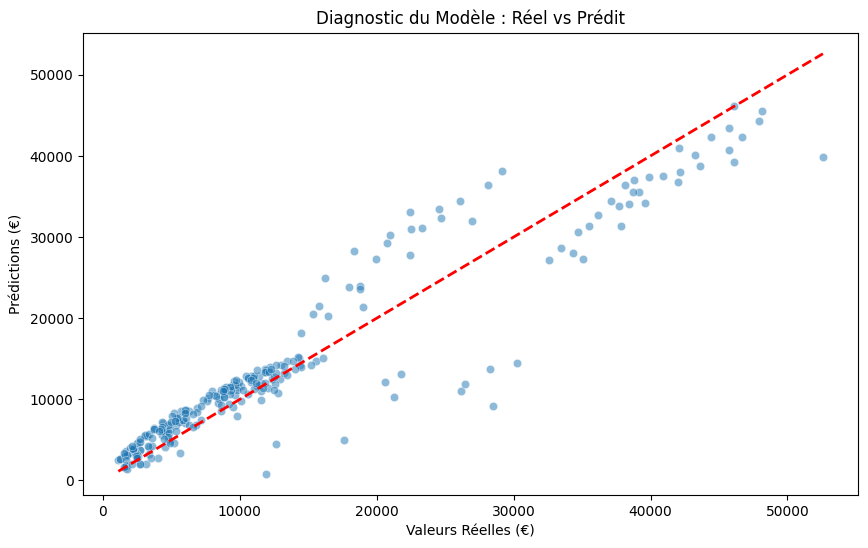

In [639]:
# Affichage d'un nuage de points pour évaluer le modèle

plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=y_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--r', lw=2)

plt.xlabel('Valeurs Réelles (€)')
plt.ylabel('Prédictions (€)')
plt.title('Diagnostic du Modèle : Réel vs Prédit')
plt.show()